## Installation

In [1]:
!pip install gdown
!pip install tamu_csce_636_project1

## M-Height Calculation Using Linear Programming

In [ ]:
import numpy as np
from scipy.optimize import linprog
from itertools import combinations, product


def compute_hm(G, m):
    """
    G: 2-D numpy array
    m: int
    """
    k, n = G.shape
    max_hm = 0

    # Iterate over all possible tuples (a, b, X, psi)
    for a in range(n):
        for b in range(n):
            if a == b:
                continue

            # Generate all subsets X of size m-1 from [n] excluding {a, b}
            remaining_indices = [j for j in range(n) if j != a and j != b]
            for X in combinations(remaining_indices, m - 1):

                # Generate all possible binary vectors psi of length m
                for psi in product([-1, 1], repeat=m):
                    # Solve LP for this tuple (a, b, X, psi)
                    z = solve_lp(G, a, b, X, psi, m)

                    # Update max_hm if necessary
                    max_hm = max(max_hm, z)

    return max_hm


def solve_lp(G, a, b, X, psi, m):
    k, n = G.shape

    # Constraints for j in Y
    Y = [j for j in range(n) if j not in X and j != a and j != b]

    # Tau
    tau = [0] * n
    tau[0] = a
    for j in range(1, m):
        tau[j] = X[j - 1]
    tau[m] = b
    for j in range(n - m - 1):
        tau[m + 1 + j] = Y[j]

    # Tau Inverse
    tau_inv = [0] * n
    for i in range(n):
        tau_inv[tau[i]] = i

    # Objective function: maximize sum(s[0] * g[i,a] * u[i])
    c = -np.array([psi[0] * G[i, a] for i in range(k)])  # Negated for minimization

    # Constraints
    A_ub = []
    b_ub = []

    for j in X:
        s_tau_j = psi[tau_inv[j]]
        A_ub.append([s_tau_j * G[i, j] - psi[0] * G[i, a] for i in range(k)])
        b_ub.append(0)

        A_ub.append([-s_tau_j * G[i, j] for i in range(k)])
        b_ub.append(-1)

    # Constraints for column b
    A_eq = [[G[i, b] for i in range(k)]]
    b_eq = [1]

    for j in Y:
        A_ub.append([G[i, j] for i in range(k)])
        b_ub.append(1)

        A_ub.append([-G[i, j] for i in range(k)])
        b_ub.append(1)

    # Solve LP using linprog
    res = linprog(
        c=c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=[(None, None)] * k,
        method="highs",
    )

    if res.status == 3:
        return float("inf")
    if res.success:
        return -res.fun  # Negate because we minimized negative objective
    else:
        return 0  # Infeasible


# Each record is of form [generator_matrix, m, m_height]
records = [
    [
        np.array(
            [
                [1.0, 0.0, 0.4759809, 0.9938236, 0.819425],
                [0.0, 1.0, -0.8960798, -0.7442706, 0.3345122],
            ]
        ),
        2,
        1.9242387,
    ],
    [
        np.array(
            [
                [1.0, 0.4759809, 0.9938236, 0.819425, 0.0],
                [0.0, -0.8960798, -0.7442706, 0.3345122, 1.0],
            ]
        ),
        2,
        1.9242387,
    ],
    [
        np.array(
            [
                [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, -0.761, -0.761, -1.85, -1.85],
                [0.0, 0.0, 1.0, 1.0, 0.0, 0.0, -0.665, -0.665, 0.715, 0.715],
                [0.0, 0.0, 0.0, 0.0, 1.0, 1.0, -0.748, -0.748, -0.609, -0.609],
            ]
        ),
        5,
        5.97,
    ],
    [
        np.array(
            [
                [1.0, 0.0, 0.0, 0.0, 0.0, -0.761, -0.761, -1.85, -1.85, 1.0],
                [0.0, 1.0, 1.0, 0.0, 0.0, -0.665, -0.665, 0.715, 0.715, 0.0],
                [0.0, 0.0, 0.0, 1.0, 1.0, -0.748, -0.748, -0.609, -0.609, 0.0],
            ]
        ),
        5,
        5.97,
    ],
    [
        np.array(
            [
                [1.0, 0.0, 0.0, 0.7, -0.791, 0.043],
                [0.0, 1.0, 0.0, -0.647, 0.833, 1.162],
                [0.0, 0.0, 1.0, 0.311, 1.284, 1.028],
            ]
        ),
        2,
        2.87,
    ],
    [
        np.array(
            [
                [1.0, 0.0, 0.0, 0.0, 0.0, 0.481, -0.917, -1.054, -1.92, 0.053],
                [0.0, 1.0, 0.0, 0.0, 0.0, -0.131, 1.088, 1.252, 0.611, 1.447],
                [0.0, 0.0, 1.0, 0.0, 0.0, -0.664, -0.214, -0.6, -1.374, 0.131],
                [0.0, 0.0, 0.0, 1.0, 0.0, -1.139, -1.8, 1.008, -1.216, 0.782],
                [0.0, 0.0, 0.0, 0.0, 1.0, -0.693, 0.812, 0.957, 0.895, 1.457],
            ]
        ),
        4,
        29.80,
    ],
]

validate_m_height = False

if validate_m_height:
  for i in range(len(records)):
      hm = compute_hm(records[i][0], records[i][1])
      print(f"Calculated m_height: {hm}, Ground Truth: {records[i][2]}")


### Some of the examples are column-permutation of other examples. I find the column permutation does not change the m-height. I used this property for data augmentation purpose.

## Dataset Generation

Generated 21,000 generator matrices and corresponding m-heights ( 1000 for each (k,m,n) combination). Used these data for testing the model. \\

For training and validation, I have used dataset collected from other students (10,000,000 across all (k,m,n) combinations, 70% used for training, 30% used for validation)

In [ ]:
import numpy as np
from collections import defaultdict
import argparse
import random
import os
import concurrent.futures
from functools import partial
import pandas as pd
import joblib

def store_dataset(df, file_name):
    joblib.dump(df, filename=file_name, compress=True)

def load_dataset(file_name):
    df = joblib.load(file_name)
    return df

def is_full_rank(matrix):
    rank = np.linalg.matrix_rank(matrix)
    return rank == min(matrix.shape)

def random_generator(k, n):
    identity_matrix = np.eye(k)
    random_matrix = np.random.uniform(-100, 100, (k, n - k))
    generator = np.hstack((identity_matrix, random_matrix))
    return is_full_rank(generator), generator, random_matrix

def process_dataset(k, n, m, count):
    d = f"dataset/generated/k{k}-n{n}-m{m}.pkl"
    records = []
    for i in range(count):
        full_rank, generator, random_matrix = random_generator(k, n)
        if not full_rank:
            continue
        m_height = compute_hm(generator, m)
        if m_height == float('inf'):
            continue
        record = {
            "n": n,
            "k": k,
            "m": m,
            "result": m_height,
            "G": generator,
            "P": random_matrix
        }
        records.append(record)
    df = pd.DataFrame(records)
    return d, df

def main(override=False, count=1000):
    dataset_path = "dataset/generated"
    datasets = defaultdict(pd.DataFrame)
    if not override:
        for file_name in [os.path.join(dataset_path, f) for f in os.listdir(dataset_path)]:
            datasets[file_name] = load_dataset(file_name)

    tasks = [(k, n, m) for k in [4, 5, 6] for n in [9, 10] for m in range(2, n-k+1) if not os.path.exists(f"dataset/generated/k{k}-n{n}-m{m}.pkl") ]
    print("Remaining tasks: ", len(tasks))

    # Use ProcessPoolExecutor to utilize multiple CPUs
    with concurrent.futures.ProcessPoolExecutor() as executor:
        futures = {executor.submit(process_dataset, k, n, m, count=count): (k, n, m) for k, n, m in tasks}

        # Collect results from each process and update datasets
        for future in concurrent.futures.as_completed(futures):
            try:
                d, df = future.result()  # Get results from the process
                datasets[d] = pd.concat([datasets[d], df], ignore_index=True)
                store_dataset(datasets[d], d)  # Save the updated dataset to disk
            except Exception as e:
                print(f"Error occurred: {e}")

# main(count=1000)


## Utility Functions

In [ ]:
import os
import gdown
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json

def get_model_names():
  model_names = []
  for k in [4, 5, 6]:
        for n in [9, 10]:
            for m in range(2, n-k+1):
                model_name = f"transformer-{k}-{n}-{m}"
                model_names.append(model_name)
  return model_names

def download(dir_path, url, quiet=True):
    os.makedirs(dir_path, exist_ok=True)
    gdown.download_folder(url, output=dir_path, quiet=quiet, use_cookies=True)
    print("Download Complete")

def load_history(model_name):
    try:
        with open(f"training_history/{model_name}_history.json", "r") as f:
            loaded_history = json.load(f)
    except FileNotFoundError:
        loaded_history = {}
    return loaded_history

def create_history_plot(history, metric, model_name, start_index=0):
  k, n, m = map(int, model_name.split("-")[1:])
  plt.figure(figsize=(6, 4))
  loss_values = history[metric]
  val_loss_values = history[f"val_{metric}"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs[start_index:], loss_values[start_index:], "bo", label=f"Training {metric}")
  plt.plot(epochs[start_index:], val_loss_values[start_index:], "b", label=f"Validation {metric}")
  plt.title(f"Training and validation {metric} (k={k}, n={n}, m={m})")
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend()
  plt.savefig(f"training_history_plots/{model_name}.png")
  plt.close()

def plot_images(model_names, image_per_row=3):
  image_files = [f"training_history_plots/{model_name}.png" for model_name in model_names]

  # Number of rows and columns
  n_rows = len(image_files) // image_per_row + (1 if len(image_files) % image_per_row != 0 else 0)
  n_cols = image_per_row

  # Create subplots
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows * 4))

  axes = axes.flatten()

  # Loop through images and plot them
  for i, file in enumerate(image_files):
      img = mpimg.imread(file)  # Read the image
      axes[i].imshow(img)       # Display the image
      axes[i].axis('off')       # Turn off axis for cleaner display

  # Turn off unused subplots if the number of images is not a multiple of image_per_row
  for j in range(len(image_files), len(axes)):
      axes[j].axis('off')

  plt.tight_layout()
  plt.show()


## Data URLs

In [ ]:
trained_best_models_url = 'https://drive.google.com/drive/folders/1AFnke960MJ85t1KA97gyBFo_DKuaX_Ul?usp=sharing'
training_history_url = 'https://drive.google.com/drive/folders/1BCuMPvRUA5iZc2u4bppWFrqEikB7_4Pa?usp=sharing'
train_data_url = 'https://drive.google.com/drive/folders/1fzgCJ3dk8pEGRxwR8Am33UxnkjNnGtJB'
test_data_url = 'https://drive.google.com/drive/folders/17AxVWbcConcUt0s3UV79VCtI5wjFm6u8'

## Download train and test dataset

In [ ]:
# download("dataset/train", train_data_url)

In [ ]:
download("dataset/test", test_data_url)

Download Complete


## Download trained models and training history
Due to google drive API rate limit, manually uploaded trained_best_models and training_history

In [ ]:
# download("trained_best_models", trained_best_models_url)

In [ ]:
# download("training_history", training_history_url)

In [ ]:
!unzip -q trained_best_models.zip

In [ ]:
!unzip -q training_history.zip

## Plot Training History

In [ ]:
!mkdir training_history_plots

In [ ]:
model_names = get_model_names()
for model_name in model_names:
    history = load_history(model_name)
    create_history_plot(history, "loss", model_name, start_index=0)

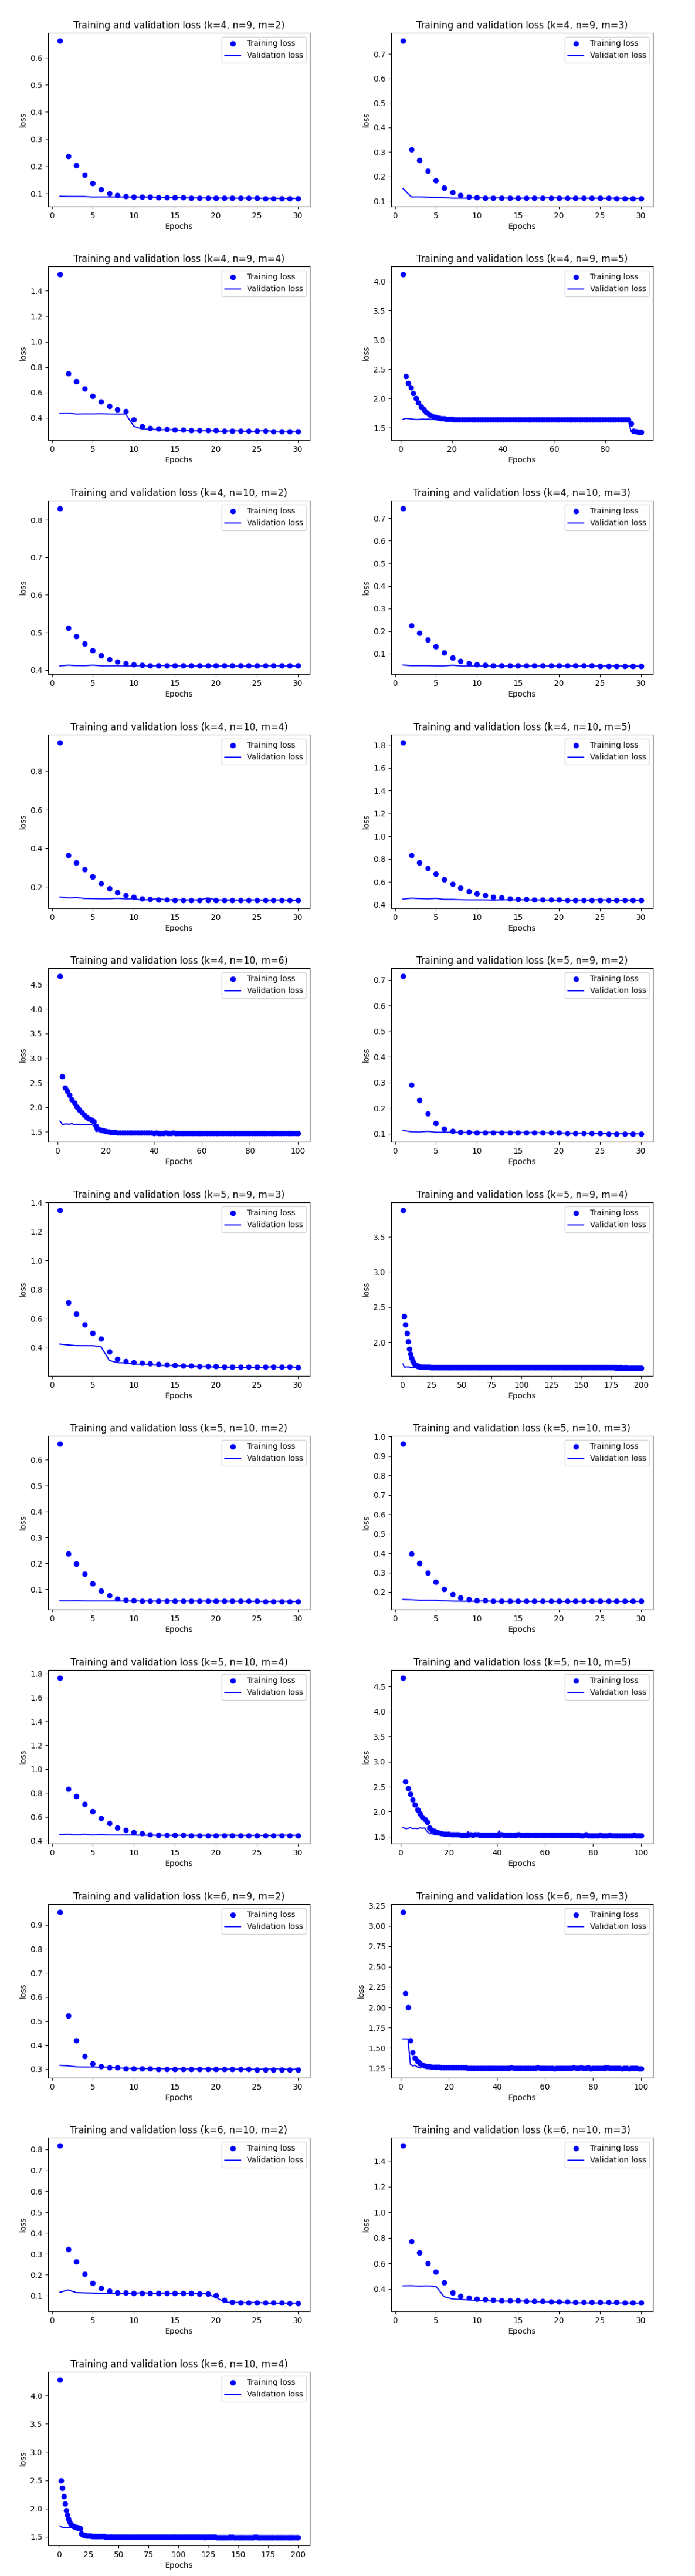

In [ ]:
plot_images(model_names, image_per_row=2)

## Model

### Custom Layers

Created `PositionalEmbedding` and `TransformerEncoder` custom layers.

*   The `PositionalEmbedding` layer recieves (r x embed_dim) input and adds sinusoidal positional encodings to it. r = k * (n-k)
*   The `TransformerEncoder` layer employs a Multi-Head attention mechanism, a two-layer feed-forward network, and two layer normalizations. It processes an input of shape (r x embed_dim) and produces an output of the same shape, (r x embed_dim).

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from keras.saving import register_keras_serializable
from tensorflow.keras import layers
import numpy as np

@register_keras_serializable(package="custom_layers", name="PositionalEmbedding")
class PositionalEmbedding(layers.Layer):
    def __init__(self, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)

        position = np.arange(input_dim)[:, np.newaxis]
        div_term = np.exp(np.arange(0, output_dim, 2) * -(np.log(10000.0) / output_dim))
        pe = np.zeros((input_dim, output_dim))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pos_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        pos_enc = self.pos_encoding[:, :self.input_dim, :]
        return inputs + pos_enc

    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "input_dim": self.input_dim,
        })
        return config


@register_keras_serializable(package="custom_layers", name="TransformerEncoder")
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=num_heads*2)
        self.dense_proj = tf.keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(1),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def build(self, input_shape):
        super().build(input_shape)

    def call(self, inputs):
        attention_output = self.attention(inputs, inputs)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config


### Build Model

The input matrix (Shape: (n-k) x k ) is first reshaped and passed through a `PositionalEmbedding` layer. It then undergoes multiple `TransformerEncoder` layers, followed by a Global Max Pooling operation, dropout layers, and dense layers, ultimately predicting a single output using a ReLU activation. The model is compiled with the Adam optimizer and mean squared error (MSE) loss. Since the model is trained on the logarithm of the actual m-height, the ReLU activation function is ideal for the output layer, as its minimum value of 0 corresponds to an exponent of 1, which is the minimum possible value for m-height.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

def build_model(k, n, num_heads=4, embed_dim=32, dense_dim=256, encoder_layers=4, dropout=0.3):
    sequence_length = k * (n-k)
    inputs = tf.keras.Input(shape=(k, n-k))
    x = tf.keras.layers.Reshape((sequence_length, 1))(inputs)
    x = PositionalEmbedding(sequence_length, output_dim=embed_dim)(x)
    for i in range(encoder_layers):
        x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128)(x)
    x = layers.Dropout(dropout)(x)
    # Model is trained on log of actual m-height. So, relu works fine. Mininum value of relu is 0, of which exp is 1 which is minimum for m-height
    outputs = layers.Dense(1, activation='relu')(x)
    model = tf.keras.Model(inputs, outputs)
    # Since model is trained on log of the actual m-height, MSE error is a good loss function to use.
    model.compile(optimizer='adam',
                loss="mse",
                metrics=["mse"])
    return model


## Model Architecture for k=4, n=9

In [ ]:
model = build_model(k=4, n=9, num_heads=2, embed_dim=64, dense_dim=32, encoder_layers=8, dropout=0.5)
print(model.summary())

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 20, 64)         │             0 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 20, 64)         │         4,505 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 20, 64)         │         4,505 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 20, 64)         │         4,505 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, 20, 64)         │         4,505 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_4           │ (None, 20, 64)         │         4,505 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_5           │ (None, 20, 64)         │         4,505 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_6           │ (None, 20, 64)         │         4,505 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_7           │ (None, 20, 64)         │         4,505 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,489 (173.79 KB)

 Trainable params: 44,489 (173.79 KB)

 Non-trainable params: 0 (0.00 B)

None


## Build Dataset
The models are trained with log value of actual m-height.
Inverse operation (exp) should be applied on the model output \\
Data augmentation is applied. For each input matrix, three augmented data is created. \\
Augmented matrix are column permutations of original matrix. Augmented data is valid becore m-height of the generator matrix is column-permutation invariant.

In [ ]:
import joblib
import os
import numpy as np
import tensorflow as tf
import gdown
import math

def multi_permute(x, num_permutations=3):
    """Generates multiple permutations of input columns"""
    return tf.stack([tf.transpose(tf.random.shuffle(tf.transpose(x))) for _ in range(num_permutations)], axis=0)

def create_augmented_dataset(data, labels, num_permutations=3):
    """Creates dataset with original + augmented samples"""

    base_ds = tf.data.Dataset.from_tensor_slices((data, labels))
    base_ds = base_ds.map(lambda x, y: (tf.cast(x, tf.float32), tf.cast(y, tf.float32)))

    augmented_ds = base_ds \
        .map(lambda x, y: (multi_permute(x, num_permutations),
                          tf.repeat(tf.expand_dims(y, 0), num_permutations, axis=0)),
             num_parallel_calls=tf.data.AUTOTUNE) \
        .flat_map(lambda x, y: tf.data.Dataset.from_tensor_slices((x, y)))

    return base_ds.concatenate(augmented_ds)

def build_dataset(k, n, m, dir_path, batch_size=32, validation_split = 0.5):
    file = f"{dir_path}/k{k}-n{n}-m{m}.pkl"
    df = joblib.load(file)
    features = np.stack(df["P"].values/100)
    labels = np.log(df["result"].values) # log of actual m-height. Inverse operation (exp) should be applied on the model output

    dataset = create_augmented_dataset(features, labels, num_permutations=3)
    dataset = dataset.shuffle(buffer_size=100000)

    total = len(labels) * 4 # Multiply original number by 4 due to augmentation
    train_size = int(total * (1 - validation_split))
    train_dataset = dataset.take(train_size).batch(batch_size).prefetch(tf.data.AUTOTUNE).repeat()
    val_dataset = dataset.skip(train_size).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    steps_per_epoch = math.ceil(train_size / batch_size)
    return train_dataset, val_dataset, steps_per_epoch


## Training
Training was completed on a separate computer and the trained models were uploaded here.


In [ ]:
import os
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import Callback


def get_last_epoch(model_name):
    try:
        with open(f"training_progress/{model_name}-progress.txt", 'r') as f:
            last_epoch = int(f.read())
    except FileNotFoundError:
        last_epoch = 0
    return last_epoch

class EpochSaver(Callback):
    def __init__(self, model_name):
        super().__init__()
        self.model_name = model_name

    def on_epoch_end(self, epoch, logs=None):
        with open(f"training_progress/{self.model_name}-progress.txt", 'w') as f:
            f.write(str(epoch))

def train(n, k, m, epochs=50):
    model = build_model(k, n, num_heads=2, embed_dim=64, dense_dim=32, encoder_layers=8, dropout=0.5)
    train_dataset, val_dataset, steps_per_epoch = build_dataset(k, n, m, "dataset/train", batch_size=1024, validation_split = 0.3)
    model_name = f"transformer-{k}-{n}-{m}"
    initial_epoch = get_last_epoch(model_name)
    if os.path.exists(f"trained_latest_models/{model_name}-latest.keras"):
        custom_objects = {
            "TransformerEncoder": TransformerEncoder,
            "PositionalEmbedding": PositionalEmbedding,
        }
        model = keras.models.load_model(f"trained_latest_models/{model_name}-latest.keras", custom_objects=custom_objects, safe_mode=False)

    callbacks = [ keras.callbacks.ModelCheckpoint(f"trained_best_models/{model_name}.keras", save_best_only=True), keras.callbacks.ModelCheckpoint(f"trained_latest_models/{model_name}-latest.keras", save_best_only=False, save_freq='epoch'),  EpochSaver(model_name)]

    initial_history = load_history(model_name)
    new_history = model.fit(train_dataset, steps_per_epoch=steps_per_epoch, epochs=epochs, initial_epoch=initial_epoch, callbacks=callbacks, validation_data=val_dataset)
    combined_history = {
        key: initial_history.get(key, []) + new_history.history[key]
        for key in new_history.history
    }
    with open(f"training_history/{model_name}_history.json", "w") as f:
        json.dump(combined_history, f)
    create_history_plot(combined_history, "loss", model_name, start_index=2)


In [ ]:
training_mode_enabled = False

In [ ]:
os.makedirs("training_history_plots", exist_ok=True)
os.makedirs("training_progress", exist_ok=True)
os.makedirs("trained_latest_models", exist_ok=True)
os.makedirs("trained_best_models", exist_ok=True)
os.makedirs("training_history", exist_ok=True)
if training_mode_enabled:
    for k in [4, 5, 6]:
        for n in [9, 10]:
            for m in range(2, n-k+1):
                train(n=n, k=k, m=m, epochs=30)

## Evaluation

In [ ]:
import tensorflow as tf
from tensorflow import keras
import joblib
import numpy as np


def inference(n, k, m, p_list):
    """
    Parameters:
        n (int)
        k (int)
        m (int)
        p_list (list): a list of P matrices, each matrix will be a numpy array

    Returns:
        a list of scalars, e.g. the m-height value, one for each matrix
    """
    model_name = f"transformer-{k}-{n}-{m}"
    custom_objects = {
        "TransformerEncoder": TransformerEncoder,
        "PositionalEmbedding": PositionalEmbedding,
    }
    model = keras.models.load_model(f"trained_best_models/{model_name}.keras", custom_objects=custom_objects, safe_mode=False)
    tensor = tf.convert_to_tensor(p_list)
    tensor = tensor/100
    output = model(tensor)
    output = np.exp(output.numpy()).flatten().tolist() ## Since the models were trained with log value of actual m-heights, exponent operation should be applied to the model output.
    return output

def load_test_data(k, n, m, dir_path):
    file = f"{dir_path}/k{k}-n{n}-m{m}.pkl"
    df = joblib.load(file)
    features = np.stack(df["P"].values)
    labels = df["result"].values
    return [features[i] for i in range(features.shape[0])], [labels[i] for i in range(labels.shape[0])]

In [8]:
from tamu_csce_636_project1 import Evaluator
import json

evaluator = Evaluator(
    first_name="Mahbub",
    last_name="Alam",
    email="mahbub.alam@tamu.edu",
    print=False,
)

inputs = {}
outputs = {}
for k in [4, 5, 6]:
    for n in [9, 10]:
        for m in range(2, n-k+1):
            features, labels = load_test_data(k=k, m=m, n=n, dir_path="dataset/test")
            inputs[f'[{n},{k},{m}]'] = features
            outputs[f'[{n},{k},{m}]'] = labels

result = evaluator.eval(
    func=inference,
    inputs=inputs,
    outputs=outputs
)

formated_result = {f"n{key[0]}-k{key[1]}-m{key[2]}": value for key, value in dict(result).items()}

print(json.dumps(formated_result, indent=4))
average = np.mean(list(formated_result.values()))
print(f"Average: {average}")

{
    "n9-k4-m2": 0.17431119047159827,
    "n9-k4-m3": 0.19698986021680184,
    "n9-k4-m4": 0.6328078369869202,
    "n9-k4-m5": 3.13821775080226,
    "n10-k4-m2": 0.8424457147043161,
    "n10-k4-m3": 0.0838330116208795,
    "n10-k4-m4": 0.3036044545942082,
    "n10-k4-m5": 0.8232813639983072,
    "n10-k4-m6": 3.2667796773311233,
    "n9-k5-m2": 0.2284037760665592,
    "n9-k5-m3": 0.5892483880985672,
    "n9-k5-m4": 3.501924902680968,
    "n10-k5-m2": 0.10322416665832199,
    "n10-k5-m3": 0.32247781022386623,
    "n10-k5-m4": 0.9719853337515508,
    "n10-k5-m5": 2.9742296629930673,
    "n9-k6-m2": 0.5370611873322628,
    "n9-k6-m3": 2.748081396455628,
    "n10-k6-m2": 0.1350436301961896,
    "n10-k6-m3": 0.6318963034580288,
    "n10-k6-m4": 3.4527611732174863
}
Average: 1.2218385043742337


## Entry Point



1.   Unzip `trained_best_models.zip`. There will be 21 models inside `trained_best_models` directory. Model name format is `transformer-{k}-{n}-{m}.keras`
2.   The `inference` function takes `n`, `k`, `m`, and `p_list` parameters and returns a list containing m-heights corresponding to each `P` matrix in `p_list`.



In [7]:
!unzip -q trained_best_models.zip

In [4]:
import tensorflow as tf
from tensorflow import keras
import joblib
import numpy as np
from tensorflow.keras import layers
from keras.saving import register_keras_serializable

def inference(n, k, m, p_list):
    """
    Parameters:
        n (int)
        k (int)
        m (int)
        p_list (list): a list of P matrices, each matrix will be a numpy array

    Returns:
        a list of scalars, e.g. the m-height value, one for each matrix
    """
    model_name = f"transformer-{k}-{n}-{m}"
    custom_objects = {
        "TransformerEncoder": TransformerEncoder,
        "PositionalEmbedding": PositionalEmbedding,
    }
    model = keras.models.load_model(f"trained_best_models/{model_name}.keras", custom_objects=custom_objects, safe_mode=False)
    tensor = tf.convert_to_tensor(p_list)
    tensor = tensor/100
    output = model(tensor)
    output = np.exp(output.numpy()).flatten().tolist() ## Since the models were trained with log value of actual m-heights, exponent operation should be applied to the model output.
    return output

def load_test_data(k, n, m, dir_path):
    file = f"{dir_path}/k{k}-n{n}-m{m}.pkl"
    df = joblib.load(file)
    features = np.stack(df["P"].values)
    labels = df["result"].values
    return [features[i] for i in range(features.shape[0])], [labels[i] for i in range(labels.shape[0])]


@register_keras_serializable(package="custom_layers", name="PositionalEmbedding")
class PositionalEmbedding(layers.Layer):
    def __init__(self, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)

        position = np.arange(input_dim)[:, np.newaxis]
        div_term = np.exp(np.arange(0, output_dim, 2) * -(np.log(10000.0) / output_dim))
        pe = np.zeros((input_dim, output_dim))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pos_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        pos_enc = self.pos_encoding[:, :self.input_dim, :]
        return inputs + pos_enc

    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "input_dim": self.input_dim,
        })
        return config


@register_keras_serializable(package="custom_layers", name="TransformerEncoder")
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=num_heads*2)
        self.dense_proj = tf.keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(1),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def build(self, input_shape):
        super().build(input_shape)

    def call(self, inputs):
        attention_output = self.attention(inputs, inputs)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

def build_model(k, n, num_heads=4, embed_dim=32, dense_dim=256, encoder_layers=4, dropout=0.3):
    sequence_length = k * (n-k)
    inputs = tf.keras.Input(shape=(k, n-k))
    x = tf.keras.layers.Reshape((sequence_length, 1))(inputs)
    x = PositionalEmbedding(sequence_length, output_dim=embed_dim)(x)
    for i in range(encoder_layers):
        x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128)(x)
    x = layers.Dropout(dropout)(x)
    # Model is trained on log of actual m-height. So, relu works fine. Mininum value of relu is 0, of which exp is 1 which is minimum for m-height
    outputs = layers.Dense(1, activation='relu')(x)
    model = tf.keras.Model(inputs, outputs)
    # Since model is trained on log of the actual m-height, MSE error is a good loss function to use.
    model.compile(optimizer='adam',
                loss="mse",
                metrics=["mse"])
    return model
